# Full example

## Let's bring it all together

Now, let us try to bring it all together to fully see what we can do with all of this together.
For this let us:

1. Get a list of Wikipedia articles about politicians and for each article the number of unique editors, the gender classification and the 'quality rating'
2. For each contributor to those articles: Get the number of politician pages they contributed to that are male/female and calculate a "specialisation" score (ratio of male/female articles edited)
3. For each politician article: sum over all specialisation scores for the editors, and plot against # of editors overall and ['quality rating'](https://en.wikipedia.org/wiki/Wikipedia:Content_assessment)

## Getting the articles

As we have seen before, there are around 1,000 Wikidata entries about Kenyan politicians.
To keep things manageable for our test. Let's start with a smaller number, and let's also again try to get a more balanced sample of pages with respect to gender.

### Some initial setup

Let's load our libraries and prepare some functions we'll be using to get this data. 

### Reminder: The ethics of working with Wikipedia data

Most contributions to Wikipedia are made by real human beings – and even the bots that edit are run by people.
It's important to keep this in mind when working with this data.

While all user names, their edits etc. are publicly visible on Wikipedia, it's still good practice to de-identify them when publishing things like scientific articles or teaching materials like these.
For that reason, in our data gathering step below, we replace the Wikipedia usernames with unique identifiers. 

### Classifying accounts as bots

For some later steps, we will be interested in differentiating between Wikipedia edits made by accounts that are bots and those made by humans. 
As a first approach, we want to just classify accounts based on whether their name includes *bot* or not.
As we anonymize the names of the contributors, we need to do this check at this stage already, you will see why later on.

**Also note:** For now we are using a very lazy approach of just checking if `bot` or `Bot` appears as a substring in the name of an account – this is **not reliable** - there will accidental mismatches (c.f. the [Scunthorpe problem](https://en.wikipedia.org/wiki/Scunthorpe_problem)) and some bot accounts might not carry *bot* in the name. For a more rigorous check, you should check the Wikipedia user groups, as outlined in the introduction! Despite those caveats, we will use this as a first step, to avoid querying the API some thousands of times.

In [2]:
import pywikibot # loading the pywikibot library
from pywikibot import pagegenerators as pg # import the page generator so we can iterate over all returned Wikidata items

import pandas as pd # loading pandas for data manipulation

import hashlib # for de-identifying the contributors

WIKIPEDIA_SITE = pywikibot.Site("en", 'wikipedia') # creating an English WP site object to get page details

WIKIDATA_SITE = pywikibot.Site("wikidata", 'wikidata')


def get_gender(wikidata_item):
    '''
    Look at the property for gendre and return the
    english language gender label if present. If not,
    return "unknown" - useful when our queries do not
    presume the response
    '''
    if "P21" in wikidata_item.claims.keys():
        return wikidata_item.claims['P21'][0].target.labels['en']
    else:
        return "unknown"


def get_content_assessment(p):
    '''
    Takes a regular page object to first get the 
    associated talk page (assessments are on those)
    and then return the assessment found.
    '''
    assessment = ["FA", "FL", "FM", "A", "GA", "B", "C", "Start", "Stub"]
    tpage = p.toggleTalkPage()
    for c in tpage.categories(): # iterate over all categories
        for a in assessment: # iterate over possible asssements
            if c.title().startswith("Category:{}-Class".format(a)):
                return a # found assessment category and return  
    return None # if none found, return None


def deidentify_contributors(contributors):
    '''
    takes the contributor list with real
    usernames and converts it into sha256
    hashes instead.
    '''
    contributors = list(contributors)
    contributors = [hashlib.sha256(c.encode()).hexdigest() for c in contributors] 
    return contributors
    
def run_query(QUERY):
    '''
    Run's the handed query and returns a dictionary that contains
    the following information, for politicians that have an article
    in the English language wikipedia
    1. Item ID in wikidata
    2. name of Wikipedia page
    3. gender of politician
    4. number of unique editors
    5. quality rating
    '''
    generator = pg.WikidataSPARQLPageGenerator(QUERY, site=WIKIDATA_SITE)

    politician_data = {}

    for item in generator:
        qid = item.getID() # get unique ID
        # check that has english language article:
        if 'enwiki' in item.sitelinks.keys():
            page_title = item.sitelinks['enwiki'].canonical_title()
            page = pywikibot.Page(WIKIPEDIA_SITE, page_title)

            politician_data[qid] = {} # initialize dictionary 
            politician_data[qid]['gender'] = get_gender(item) # add gender
            politician_data[qid]['name'] = page_title # add english article name
            politician_data[qid]['content_assessment'] = get_content_assessment(page)
            contributors = list(page.contributors())
            politician_data[qid]['contributor_is_bot'] = [True if 'bot' in c.lower() else False for c in contributors] # mark if a contributor is a bot or not
            contributors = deidentify_contributors(contributors)
            politician_data[qid]['contributor_count'] = len(contributors)
            politician_data[qid]['contributor_list'] = contributors
    return politician_data

### Writing our queries and executing them

For testing purposes and not waiting for a long time for the API, Let's now get 50 articles each for male and female politicians to get us started:

(**note: currently the outputs below use *all* articles!**)

In [3]:
male_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581097; # male
}
LIMIT 1200
"""

female_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581072; # female
}
LIMIT 1200
"""

page_data_male = run_query(male_query)
page_data_female = run_query(female_query)

Now that we got our two dictionaries, we can merge them into a data frame as we've done before:

In [4]:
all_page_data = page_data_male | page_data_female
df_all_page_data = pd.DataFrame(all_page_data).T
df_all_page_data

,gender,name,content_assessment,contributor_is_bot,contributor_count,contributor_list
Q47493987,male,Samuel Atandi,Stub,"[False, False, False, False, False, False, False]",7,[aac6535862797986f92095d0bab66e17b2f5082d17593...
Q18207112,male,Samuel Moroto,Start,"[False, False, False, False, False, False, Fal...",27,[6b3d3a51e8a069af399128515babe479c52425c14f740...
Q136723142,male,John David Kali,Start,"[False, False, False, False, False, False, Fal...",17,[5ce084c4f608ddd0a136a5fde56139021d6f84bbed732...
Q5021394,male,Calist Andrew Mwatela,Stub,"[True, False, False, False, True, False, False...",32,[f8db1742eb8022428024482fe02b73bd059ca55aab0f6...
Q115690447,male,Joseph Cherorot,Start,"[False, False, False]",3,[9ad3810b6c8eb6aa458a3fdc3bc7bfdd6894f7ea8de99...
...,...,...,...,...,...,...
Q6297432,female,Joyce Laboso,Stub,"[False, False, True, False, False, False, Fals...",83,[6b3d3a51e8a069af399128515babe479c52425c14f740...
Q47494639,female,Sara Korere,Start,"[True, False, True, True, False, False, False,...",14,[b2c8031262437b162a061954c6178b79c8603b80bec12...
Q47490065,female,Jerusha Mongina Momanyi,Start,"[True, False, False, False, False, False, Fals...",10,[f8db1742eb8022428024482fe02b73bd059ca55aab0f6...
Q47539824,female,Margaret Kobia,Start,"[True, False, False, False, False, False, Fals...",22,[f8db1742eb8022428024482fe02b73bd059ca55aab0f6...


Let's look at the gender breakdown of our sample now:

In [5]:
df_all_page_data.groupby(['gender'])['name'].count()

gender
female    153
male      493
Name: name, dtype: int64

So we end up with ~3x as many male articles as female articles.

Now we got the data frame with the information we want for each article so far, along with the list of contributors.

## Classifying contributors

This allows us to now aggregate the information about the contributors and how many male/female biographies they have contributed to. For this, we iterate over all the rows we have and count how many female or male articles they have contributed to:

In [7]:
from collections import defaultdict

# the default value for our dictionary is a sub-dictionary
# this makes it easier to create a dictionary of dictionaries
# in this form:
# {'editor_name': {
#    'male': 10, 
#    'female': 15},
#  'editor_2': {
#    'male': 1, 
#    'female': 4},
#}

editors = defaultdict(dict)

for index, row in df_all_page_data.iterrows():
    for i, contributor in enumerate(row['contributor_list']):
        editors[contributor]['is_bot'] = row['contributor_is_bot'][i]
        if row['gender'] in editors[contributor].keys():
            editors[contributor][row['gender']] += 1
        else:
            editors[contributor][row['gender']] = 1

# let's convert it into a DF as well
df_editors = pd.DataFrame(editors).T
df_editors

,is_bot,male,female
aac6535862797986f92095d0bab66e17b2f5082d175932ced9b41182423bb5e4,False,39,14
b3ddd339ec4410022359ad3e679f8d9099fb6085ebd801e0d24d032306d7753c,False,118,46
6b3d3a51e8a069af399128515babe479c52425c14f740b24415c5f5aab3e8094,False,339,67
5bafe5a6cbc8384d6d24ef6a65085a96f0d4161a990ad01f8c15a57125e0f821,False,35,24
e85a82ee1ee4dd63a355b1dab9124eb1586c820aaca002d5fbe6d8e659c39584,False,1,NaN
...,...,...,...
9ecafb054e6dc53f21a03ceb3978eba7db9da2b661a09f7af06f5fbadc1200c8,False,NaN,1
95492f277d4fe95767cb1fde4f94ac68bc1beb2025eef5a2a254b5851d103721,False,NaN,1
ec53ffbdab898943e1181a32a9859747ea7c1010d84a69a2ded6d5d984ada4d5,False,NaN,1
ab0f848f32cfa8207f76b4cc5971216b0d9f903285b10354c48ea5a08e3a6c2b,False,NaN,1


As we can see, some of those values wil be `NaN` (*not a number*) as the editors haven't contributed to one of the two categories. In reality, those missing bits are `0`, so let's replace those:

In [8]:
df_editors = df_editors.fillna(0)

  df_editors = df_editors.fillna(0)



Now we can count the total number of pages the users edited (that is, pages in our sample, not the total pages they ever edited!) and then get the fraction of edits that went to male edits:

In [9]:
df_editors['total_pages'] = df_editors['male'] + df_editors['female']
df_editors['percent_male'] = df_editors['male'] /  df_editors['total_pages']  

<Axes: ylabel='Frequency'>

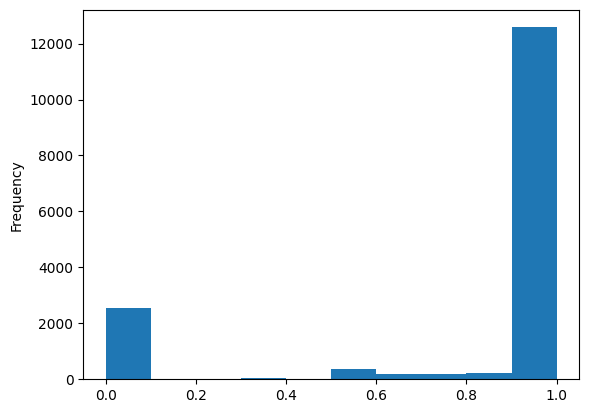

In [10]:
df_editors['percent_male'].plot(kind='hist')

That looks very strongly bi-modal. But this could be an artifact, if we remember participation inequality in Wikipedia: The vast majority of users here will have likely only done a single edit, which by definition would end up in either in the 0% or 100% group. Let's plot that number of edited pages to explore this:

<Axes: ylabel='Frequency'>

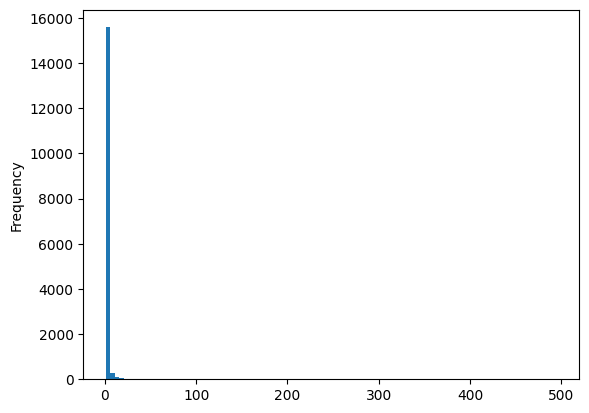

In [11]:
df_editors['total_pages'].plot(kind='hist',bins=100)

As expected, we see that the overwhemling majority of all editors only touched a single page, heavily biasing our results. Let's require people to have at least edited 2 pages to avoid this and remove the outliers:

<Axes: ylabel='Frequency'>

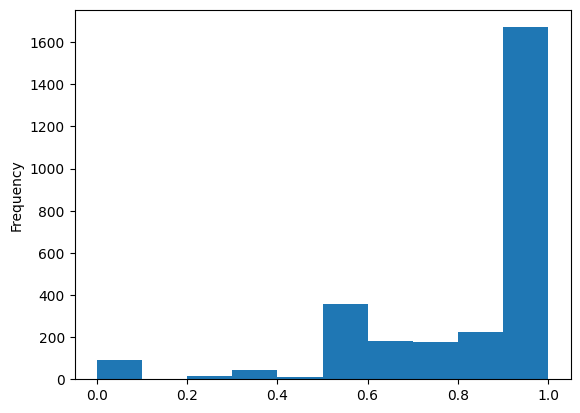

In [12]:
df_editors[df_editors['total_pages']>=2]['percent_male'].plot(kind='hist')

## Classify articles by mean specialisation score

While we still see a strong male-bias, this removes the large outliers that were purely a statistical artifact. We can now use those editor classifications to calculate the 'specialisation' score:

In [13]:
def calculate_specialisation_score(row,df_editors):
    '''
    give average "specialisation" score
    for all contributors who touched article
    and edited 2+ articles in set
    '''
    score = 0
    contribs = 0
    for contributor in row['contributor_list']:
        if contributor in df_editors.index:
            score += float(
                df_editors.loc[[contributor]]['percent_male'].iloc[0]
            )
            contribs += 1
    if contribs:
        return score / contribs
    else:
        return None

filtered_editors = df_editors[df_editors['total_pages']>=2]

df_all_page_data['specialisation_score'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.head()

,gender,name,content_assessment,contributor_is_bot,contributor_count,contributor_list,specialisation_score
Q47493987,male,Samuel Atandi,Stub,"[False, False, False, False, False, False, False]",7,[aac6535862797986f92095d0bab66e17b2f5082d17593...,0.675364
Q18207112,male,Samuel Moroto,Start,"[False, False, False, False, False, False, Fal...",27,[6b3d3a51e8a069af399128515babe479c52425c14f740...,0.808488
Q136723142,male,John David Kali,Start,"[False, False, False, False, False, False, Fal...",17,[5ce084c4f608ddd0a136a5fde56139021d6f84bbed732...,0.824885
Q5021394,male,Calist Andrew Mwatela,Stub,"[True, False, False, False, True, False, False...",32,[f8db1742eb8022428024482fe02b73bd059ca55aab0f6...,0.875989
Q115690447,male,Joseph Cherorot,Start,"[False, False, False]",3,[9ad3810b6c8eb6aa458a3fdc3bc7bfdd6894f7ea8de99...,0.740038


Now that we got the data frame above, we can actually plot our data, by comparing the specialisation score depending on the contributor count and the content assessment:

<Axes: xlabel='contributor_count', ylabel='specialisation_score'>

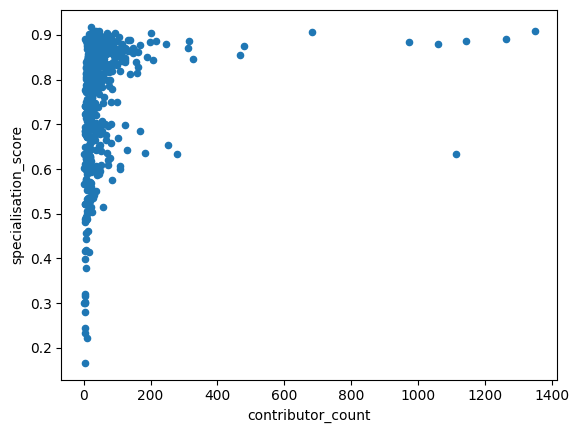

In [14]:
df_all_page_data.plot(x='contributor_count',y='specialisation_score',kind='scatter')

We see how the articles specialisation score reaches the 'average' as the number of contributors grows, approximating the distribution of gender of politicians represented in Wikidata.
But there are also some articles with a larger number of contributors, where the average specialisation score hovers around 0.6.

When we look at the 'content assessment in relation to the average specialisation, we find that the articles classified as *start* have a slightly lower score. 

specialisation_score    Axes(0.125,0.11;0.775x0.77)
dtype: object

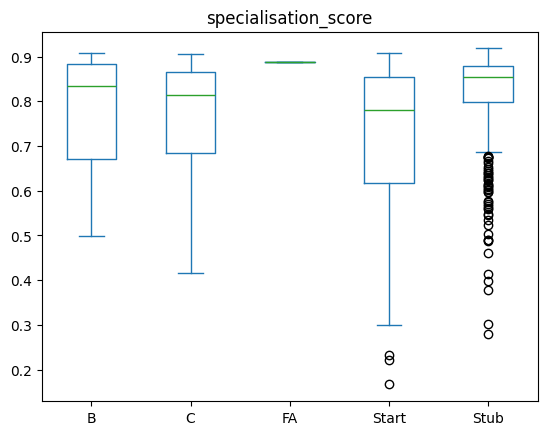

In [15]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score',kind='box')


*Start*-classified articles are generally smaller (and are comparitively newer or with fewer editors), this might be an artifact of just approximating the number of contributors. Let's see how the number of editors varies between those categories:

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

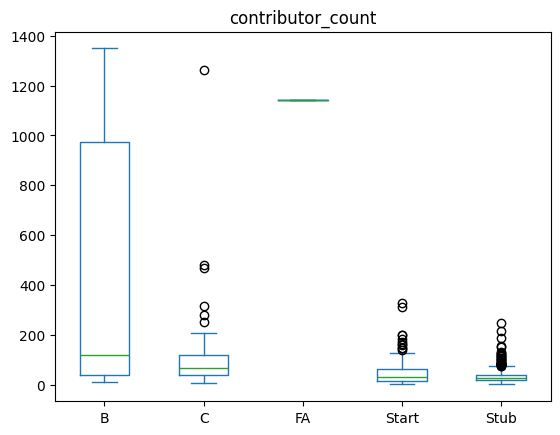

In [16]:
df_all_page_data.plot(by=['content_assessment'],column='contributor_count',kind='box')


For the *stub* articles, we see that they indeed have the smallest number of contributors - while the *start* articles have more editors and **still** have a lower specialisation score? Why could that be? 
One thing that could happen is that we are seeing the impact of targeted editing, e.g. in *Editathons* in which people contribute more fleshed-out articles (i.e. more than just *stubs*) on a given topic.

Were there maybe events for editing/adding missing pages for women in Kenya?
Those would likely be more fleshed out, immediately bypassing the *Stub* category and be at least classified as *Start*.

One thing we didn't take into account so far are bot accounts. What happens if we'd redo this whole work without bot accounts? 

To account for this, we did a very basic classification above - based on the user names, to ID which accounts are bots and which ones aren't. 

We can now use this contributor classification to remove them from the scoring, similar to how we removed accounts with only a single edit

Now we can filter for accounts with edits to 2+ pages and not carrying *bot in the name*, redo our score calculation and plot the same curve:

<Axes: xlabel='contributor_count', ylabel='specialisation_score_no_bots'>

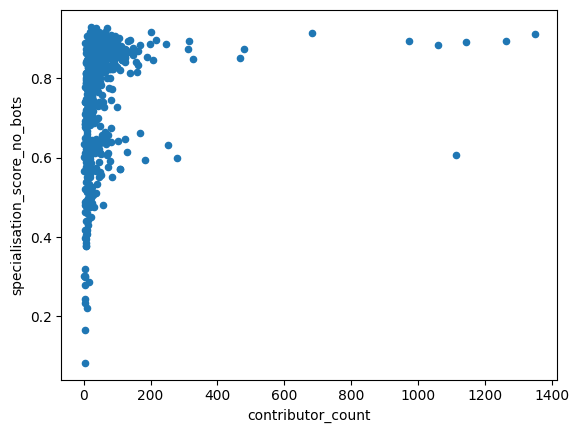

In [17]:
filtered_editors = df_editors.loc[(df_editors['total_pages']>=2) & (df_editors['is_bot'] != True)]


df_all_page_data['specialisation_score_no_bots'] = df_all_page_data.apply(
    calculate_specialisation_score,
    axis=1,
    args=[filtered_editors])

df_all_page_data.plot(x='contributor_count',y='specialisation_score_no_bots',kind='scatter')

This looks very similar to the picture we saw before!

Let's make a scatter plot to compare the per-page scores with or without bots:

<Axes: xlabel='specialisation_score', ylabel='specialisation_score_no_bots'>

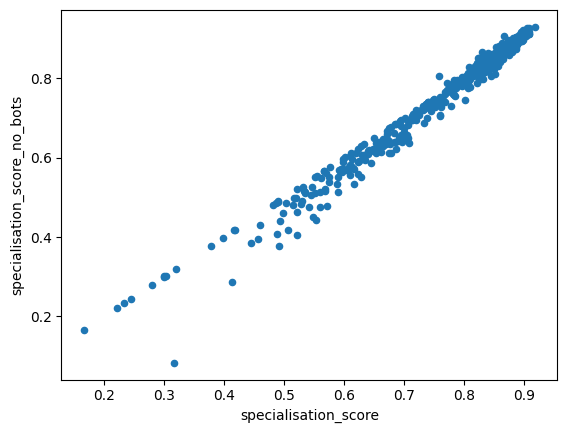

In [18]:
df_all_page_data.plot(x='specialisation_score',y='specialisation_score_no_bots',kind='scatter')

For some entries that seems to drop the calculated scores a bit, but looks quite similar overall, and we can see the same for the content assessment:

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

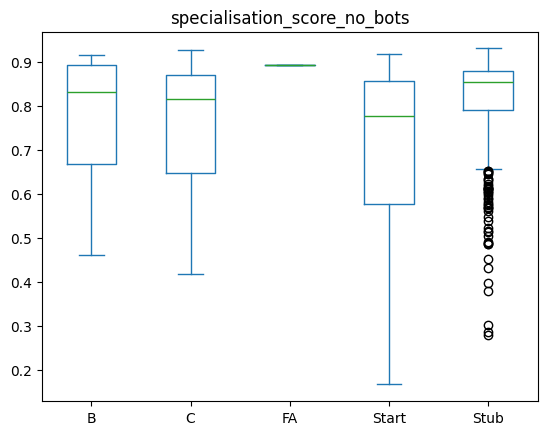

In [19]:
df_all_page_data.plot(by=['content_assessment'],column='specialisation_score_no_bots',kind='box')

This still approximates the same graph we saw before: *Start* articles are showing a less strong specialisation amongst editors.

## Specialisation depending on gender of biography

Now, let's look at the gender of the person a page is about, and see how the specialisation looks like there:

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

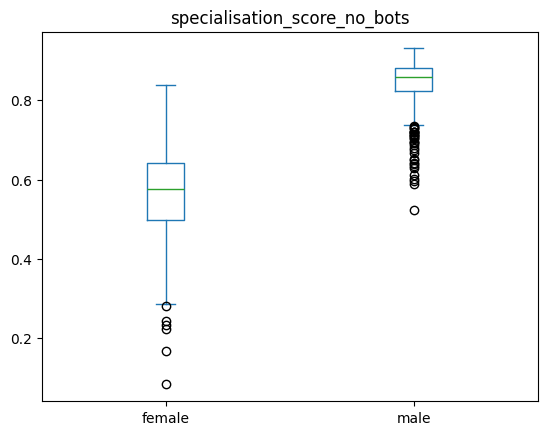

In [20]:
df_all_page_data[df_all_page_data['contributor_count'] <2000 ].plot(by=['gender'],column='specialisation_score_no_bots',kind='box')

This shows us that biographies about women show a lot less specialisation - i.e. are by a mix of contributors who contribute to male & female biographies.

In contrast, the male biographies are mostly dominated by contributors that mostly contribute to biographies of men.

Let's double check if there is a clear bias in numbers of contributors between the male & female articles?

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

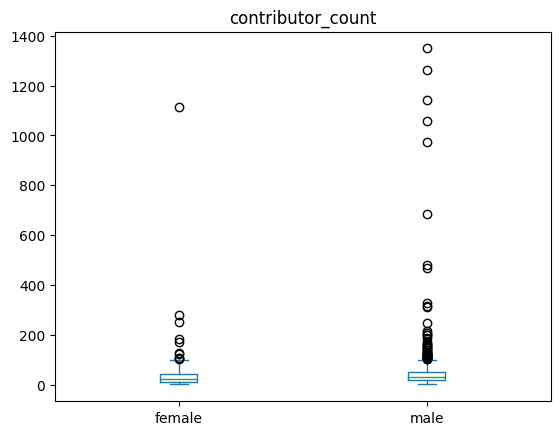

In [21]:
df_all_page_data.plot(by=['gender'],column='contributor_count',kind='box')

For the median, that does not seem to be the case, despite having some strong outliers with much larger contributor numbes for men.

# Gender, specialisation and quality

Lastly, let's now combine it all and look at a per-gender breakdown and see if there are systematic differences. First for all pages, and then removing pages that had fewer than 200 editors, to remove large outliers 

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

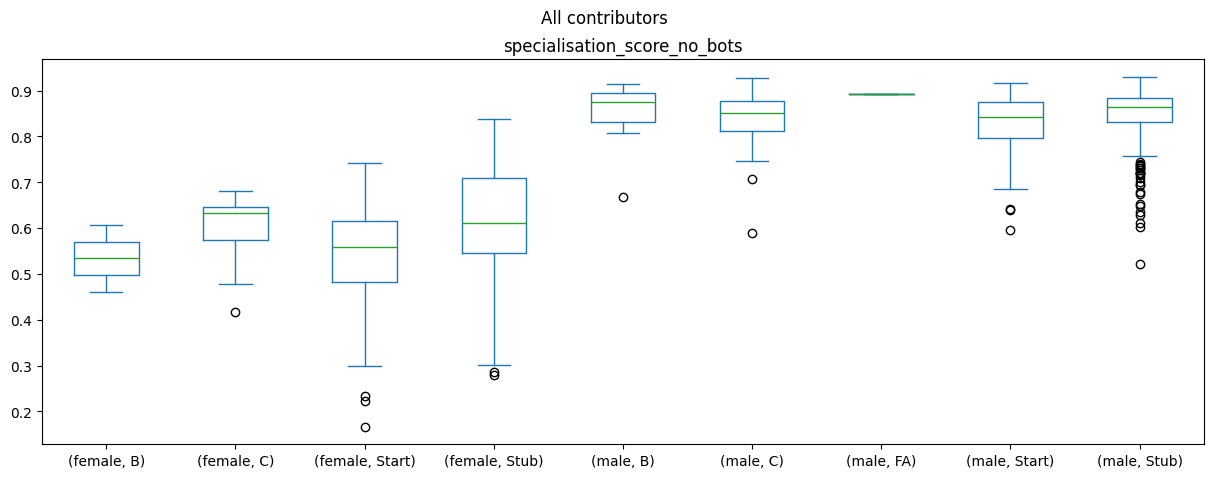

In [22]:
df_all_page_data.plot(by=['gender','content_assessment'],column='specialisation_score_no_bots',kind='box',figsize=(15,5),title='All contributors') # WITHOUT filter for articles with very large numbers of editors

specialisation_score_no_bots    Axes(0.125,0.11;0.775x0.77)
dtype: object

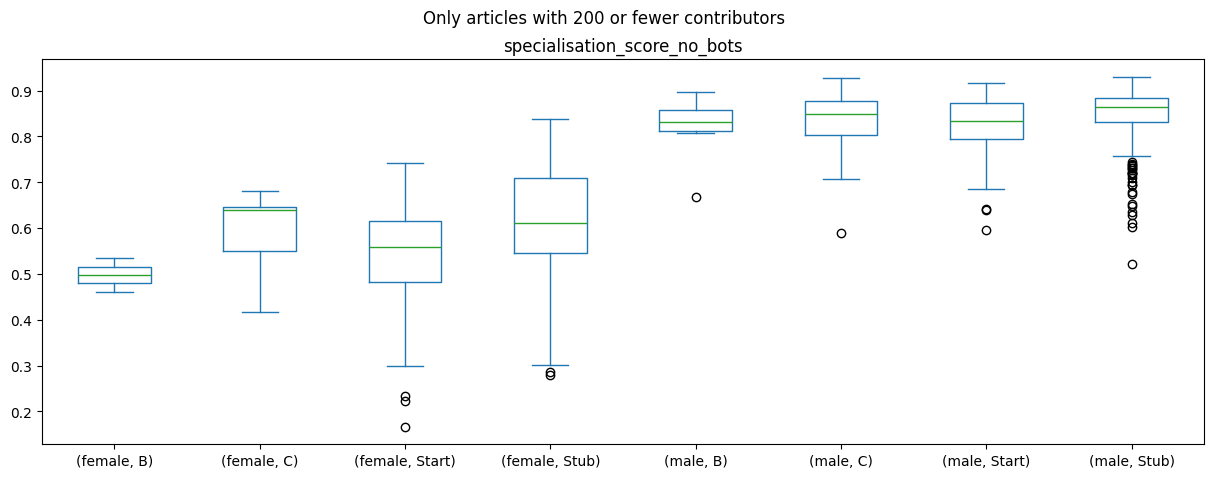

In [23]:
df_all_page_data[df_all_page_data['contributor_count'] <200 ].plot(by=['gender','content_assessment'],column='specialisation_score_no_bots',kind='box',figsize=(15,5),title="Only articles with 200 or fewer contributors") # filter for articles with very large numbers of editors

The difference between the biography gender and the specialisation score generally holds across all article content ratings, but there doesn't seem to be a strong impact or difference between the article ratings and the specialisation score.

But, maybe there is one between the article quality and number of editors? Let's make a plot for that too:

contributor_count    Axes(0.125,0.11;0.775x0.77)
dtype: object

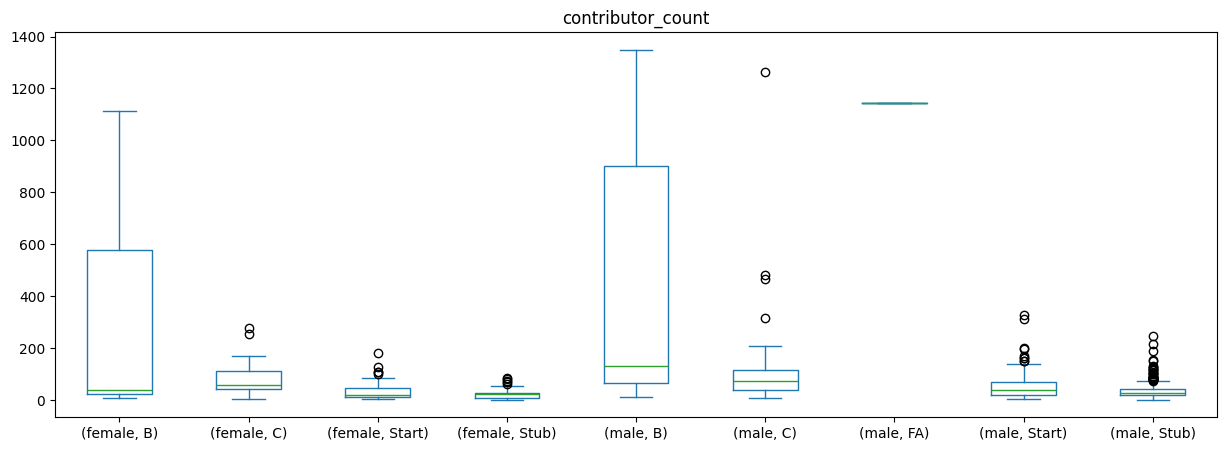

In [24]:
df_all_page_data.plot(by=['gender','content_assessment'],column='contributor_count',kind='box',figsize=(15,5)) # WITHOUT filter for articles with very large numbers of editors

This seems to indeed be roughly the case: The 'better' an article, the more people have contributed to it!

Overall, what we see is not so much of a *polarisation*, but two different editor communities: 

There are some contributors who mostly contribute to the biographies of men, while others contributors roughly equally contribute to male and female biographies.
So we do not necessarily find a strong signal for a *battle of the sexes* in our data as is.

When interpreting these findings, we should also keep a number of caveats in mind:

1. The APIs of Wikipedia only show us information about **existing pages**. Pages that were deleted, e.g. for a perceived lack of relevancy, would not be in our data
2. Existing biases in media coverage: [According to the WACC Global Media Monitor](https://waccglobal.org/our-work/global-media-monitoring-project-gmmp/) data from 2021, only 19% of news subjects in Kenya were woman. As Wikipedia articles should be referenced, a lack of news coverage makes it harder for female biographies to be added to Wikipedia.

## Statistical testing

We can now also move beyond looking at the graphs and instead do some statistical model to better understand the relationships between our variables.

For this, we will be using the `statsmodel` library.

If you haven't installed it yet, you can do so via `! pip install statsmodel` from the notebooks here! 

Once that done let's load the library:

In [25]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

To make our modeling a bit easier, we'll turn the `content_assessment` in to a binary variable for whether articles are highly ranked (e.g. are categories `FA`, `A`, `B` or `C`) or are just getting started (`Start` or `Stub`):   

In [26]:
df_all_page_data['highquality'] = df_all_page_data['content_assessment'].map(lambda x: int(x in ['C', 'B', 'FA', 'A']))

Now we'll also convert the contributor counts to the `log`:

In [27]:
import numpy as np
df_all_page_data['contributor_count'] = df_all_page_data['contributor_count'].map(lambda x: int(x))
df_all_page_data['contributor_count_log'] = df_all_page_data['contributor_count'].map(lambda x: np.log1p(x))

And with this all done, we can now run our model:

In [30]:
results = smf.ols('highquality ~ contributor_count_log + specialisation_score_no_bots + gender', data=df_all_page_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            highquality   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     34.48
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.13e-20
Time:                        13:43:40   Log-Likelihood:                -74.086
No. Observations:                 646   AIC:                             156.2
Df Residuals:                     642   BIC:                             174.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       